# Part 5 — Cross-Domain Test Evaluation

This notebook is the test-set evaluation for the CNN classification track.
The "test set" is defined as **out-of-distribution data**: images from a
dataset entirely different from the one each model was trained on.

Specifically:

- **Test 1: BHSig classifier on CEDAR data.** We take the BHSig-trained
  ResNet-18 (which knows 160 specific Hindi-script writers) and feed it
  all 2640 CEDAR signatures (which come from 55 completely different
  Latin-script writers).
- **Test 2: CEDAR classifier on BHSig data.** The symmetric experiment.
  CEDAR-trained ResNet-18 (knows 55 Latin-script writers) gets all 800
  BHSig test images.
- **Test 3 (baselines): in-domain confidence.** Same models on their own
  test data, to establish what "confident and correct" looks like.

For each test we measure:
- **Top-1 confidence** — how sure was the model of its prediction?
- **Entropy** — how spread-out was the full probability distribution?
  Low entropy = model committed to one answer; high entropy = model is
  uncertain across all classes.
- **(Test 1 only) Confidence on genuine vs forgery CEDAR images** — to
  check whether forgery acquisition artifacts leak through to the BHSig
  model's predictions.

## Imports and setup

In [1]:
import os
import re
import json
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torchvision import transforms, models, datasets

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration

These paths assume the notebook lives at the project root, alongside
`signature_cnn_final.ipynb`, `cedar_classification_v2.ipynb`,
`run_results/`, and `cedar_run_results/`.

In [2]:
# Checkpoints
BHSIG_CKPT = Path("./run_results/resnet18_allclasses_best.pt")
CEDAR_CKPT = Path("./cedar_run_results/cedar_writer_all_resnet18_best.pt")

# Data paths
BHSIG_TEST_DIR = Path("./test")        # BHSig test partition (ImageFolder layout)
CEDAR_DIR = Path("./CEDAR-Buffalo")
CEDAR_GENUINE_DIR = CEDAR_DIR / "full_org"
CEDAR_FORGERY_DIR = CEDAR_DIR / "full_forg"

# Output for failure illustrations and result JSON
PART5_RESULTS_DIR = Path("./part5_results")
PART5_RESULTS_DIR.mkdir(exist_ok=True)
ILLUSTRATIONS_DIR = PART5_RESULTS_DIR / "illustrations"
ILLUSTRATIONS_DIR.mkdir(exist_ok=True)

print("BHSig checkpoint:", BHSIG_CKPT.exists(), BHSIG_CKPT)
print("CEDAR checkpoint:", CEDAR_CKPT.exists(), CEDAR_CKPT)
print("BHSig test dir:  ", BHSIG_TEST_DIR.exists(), BHSIG_TEST_DIR)
print("CEDAR genuine:   ", CEDAR_GENUINE_DIR.exists(), CEDAR_GENUINE_DIR)
print("CEDAR forgery:   ", CEDAR_FORGERY_DIR.exists(), CEDAR_FORGERY_DIR)

BHSig checkpoint: True run_results\resnet18_allclasses_best.pt
CEDAR checkpoint: True cedar_run_results\cedar_writer_all_resnet18_best.pt
BHSig test dir:   True test
CEDAR genuine:    True CEDAR-Buffalo\full_org
CEDAR forgery:    True CEDAR-Buffalo\full_forg


## Model loading

We need to reconstruct ResNet-18 with the same head size each checkpoint
expects, then load weights. Each checkpoint stores its preprocessing
parameters, which we use to build the matching transform.

In [3]:
class InvertTransform:
    def __call__(self, img):
        return ImageOps.invert(img)


class ToThreeChannel:
    def __call__(self, tensor):
        if tensor.shape[0] == 1:
            return tensor.repeat(3, 1, 1)
        return tensor


def build_resnet18(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def load_classifier(ckpt_path, device):
    """Load a classifier checkpoint and return (model, transform, class_names,
    backbone, num_classes)."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    num_classes = ckpt["num_classes"]
    class_names = ckpt["class_names"]
    backbone = ckpt["backbone"]
    image_height = ckpt["image_height"]
    image_width = ckpt["image_width"]
    norm_mean = ckpt["norm_mean"]
    norm_std = ckpt["norm_std"]

    if backbone != "resnet18":
        raise ValueError(f"Expected resnet18 checkpoint, got {backbone}")

    model = build_resnet18(num_classes)
    model.load_state_dict(ckpt["state_dict"])
    model.eval().to(device)

    tf_steps = [
        transforms.Grayscale(num_output_channels=1),
        InvertTransform(),
        transforms.Resize((image_height, image_width)),
        transforms.ToTensor(),
        ToThreeChannel(),
        transforms.Normalize(mean=norm_mean, std=norm_std),
    ]
    transform = transforms.Compose(tf_steps)

    return model, transform, class_names, backbone, num_classes


bhsig_model, bhsig_transform, bhsig_classes, _, bhsig_n = load_classifier(BHSIG_CKPT, device)
cedar_model, cedar_transform, cedar_classes, _, cedar_n = load_classifier(CEDAR_CKPT, device)

print(f"BHSig model: {bhsig_n} classes (Hindi writers)")
print(f"CEDAR model: {cedar_n} classes (Latin writers)")

BHSig model: 160 classes (Hindi writers)
CEDAR model: 55 classes (Latin writers)


## Image collection

Three image sets to evaluate:

1. **BHSig test set** — the 800 held-out BHSig test images. Used both
   as in-domain test for the BHSig model and as OOD test for the CEDAR
   model.
2. **CEDAR genuine** — all 1320 genuine CEDAR signatures. OOD for the
   BHSig model; in-domain for the CEDAR model.
3. **CEDAR forgery** — all 1320 CEDAR forgeries. OOD for the BHSig
   model; the CEDAR model was trained for writer classification on
   genuine only, so forgeries are also OOD-ish for it (different label
   space).

In [4]:
def collect_imagefolder_paths(folder):
    """Walk an ImageFolder-style directory, return list of (writer_name, path)."""
    paths = []
    for writer_dir in sorted(folder.iterdir()):
        if not writer_dir.is_dir():
            continue
        for img in sorted(writer_dir.iterdir()):
            if img.suffix.lower() in (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"):
                paths.append((writer_dir.name, img))
    return paths


_orig_re = re.compile(r"original_(\d+)_(\d+)\.png$", re.IGNORECASE)
_forg_re = re.compile(r"forgeries_(\d+)_(\d+)\.png$", re.IGNORECASE)


def collect_cedar_paths(folder, pattern):
    paths = []
    for fname in sorted(os.listdir(folder)):
        m = pattern.search(fname)
        if m:
            writer = m.group(1)
            paths.append((writer, folder / fname))
    return paths


bhsig_test_paths = collect_imagefolder_paths(BHSIG_TEST_DIR)
cedar_genuine_paths = collect_cedar_paths(CEDAR_GENUINE_DIR, _orig_re)
cedar_forgery_paths = collect_cedar_paths(CEDAR_FORGERY_DIR, _forg_re)

print(f"BHSig test images:    {len(bhsig_test_paths)}")
print(f"CEDAR genuine images: {len(cedar_genuine_paths)}")
print(f"CEDAR forgery images: {len(cedar_forgery_paths)}")

BHSig test images:    800
CEDAR genuine images: 1320
CEDAR forgery images: 1320


## Inference helper

Returns top-1 prediction, top-1 probability, full entropy, and the full
probability vector for each image. Batched for speed.

In [5]:
@torch.no_grad()
def run_inference(model, transform, image_paths, device, batch_size=32):
    """Returns dict with arrays:
        top1_idx       (N,) int   - predicted class index
        top1_prob      (N,) float - top-1 softmax probability
        entropy        (N,) float - entropy in nats of full distribution
        true_writers   (N,) str   - true writer label (the source writer name)
    Where N = len(image_paths)."""
    n = len(image_paths)
    top1_idx = np.zeros(n, dtype=np.int32)
    top1_prob = np.zeros(n, dtype=np.float32)
    entropy = np.zeros(n, dtype=np.float32)
    true_writers = []

    buf_paths_idx = []
    buf_tensors = []

    def flush():
        if not buf_tensors:
            return
        x = torch.stack(buf_tensors).to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        # Entropy in nats: -sum(p * log p)
        log_probs = torch.log(probs.clamp_min(1e-12))
        ent = -(probs * log_probs).sum(dim=1)
        top1_p, top1_i = probs.max(dim=1)

        for k, idx in enumerate(buf_paths_idx):
            top1_idx[idx] = top1_i[k].item()
            top1_prob[idx] = top1_p[k].item()
            entropy[idx] = ent[k].item()

        buf_paths_idx.clear()
        buf_tensors.clear()

    for i, (writer, path) in enumerate(image_paths):
        true_writers.append(writer)
        img = Image.open(path)
        t = transform(img)
        buf_paths_idx.append(i)
        buf_tensors.append(t)
        if len(buf_tensors) >= batch_size:
            flush()
    flush()

    return {
        "top1_idx": top1_idx,
        "top1_prob": top1_prob,
        "entropy": entropy,
        "true_writers": true_writers,
    }

## Run all four evaluations

1. BHSig model on BHSig test images (in-domain baseline)
2. BHSig model on CEDAR genuine images (OOD)
3. BHSig model on CEDAR forgery images (OOD)
4. CEDAR model on BHSig test images (OOD, symmetric)
5. CEDAR model on CEDAR genuine images (in-domain baseline for the symmetric direction)

In [6]:
print("Running BHSig model on BHSig test images (in-domain)...")
bhsig_on_bhsig = run_inference(bhsig_model, bhsig_transform, bhsig_test_paths, device)

print("Running BHSig model on CEDAR genuine images (OOD)...")
bhsig_on_cedar_gen = run_inference(bhsig_model, bhsig_transform, cedar_genuine_paths, device)

print("Running BHSig model on CEDAR forgery images (OOD)...")
bhsig_on_cedar_forg = run_inference(bhsig_model, bhsig_transform, cedar_forgery_paths, device)

print("Running CEDAR model on BHSig test images (OOD, symmetric)...")
cedar_on_bhsig = run_inference(cedar_model, cedar_transform, bhsig_test_paths, device)

print("Running CEDAR model on CEDAR genuine images (in-domain baseline)...")
cedar_on_cedar_gen = run_inference(cedar_model, cedar_transform, cedar_genuine_paths, device)

print("Done.")

Running BHSig model on BHSig test images (in-domain)...
Running BHSig model on CEDAR genuine images (OOD)...
Running BHSig model on CEDAR forgery images (OOD)...
Running CEDAR model on BHSig test images (OOD, symmetric)...
Running CEDAR model on CEDAR genuine images (in-domain baseline)...
Done.


## In-domain accuracy (check)

For both classifiers we should still see strong accuracy on their own
in-domain test data, exactly matching what was reported in Part 4.
This confirms the checkpoints are loaded correctly.

In [7]:
# BHSig in-domain accuracy
bhsig_class_to_idx = {c: i for i, c in enumerate(bhsig_classes)}
bhsig_true_idx = np.array([bhsig_class_to_idx[w] for w in bhsig_on_bhsig["true_writers"]])
bhsig_indomain_acc = (bhsig_on_bhsig["top1_idx"] == bhsig_true_idx).mean()
print(f"BHSig model on BHSig test images:  accuracy = {bhsig_indomain_acc:.4f}")

# CEDAR in-domain accuracy (using genuine images only since the CEDAR writer
# classifier was trained on genuine)
cedar_class_to_idx = {c: i for i, c in enumerate(cedar_classes)}
cedar_true_idx = np.array([cedar_class_to_idx[w] for w in cedar_on_cedar_gen["true_writers"]])
cedar_indomain_acc = (cedar_on_cedar_gen["top1_idx"] == cedar_true_idx).mean()
print(f"CEDAR model on CEDAR genuine images: accuracy = {cedar_indomain_acc:.4f}")

BHSig model on BHSig test images:  accuracy = 0.9962
CEDAR model on CEDAR genuine images: accuracy = 0.9970


## Out-of-distribution analysis


For OOD data, we cannot measure accuracy in the usual sense — the
predicted "writer ID" is structurally meaningless because none of the
target writers are in the model's vocabulary. Instead, we measure two
proxies:

- **Mean top-1 probability**. A confident prediction means the model is
  very sure of an answer that, on OOD data, has a high probability of
  being wrong. Lower confidence on OOD is the desired behavior.
- **Mean entropy**. Maximum entropy for a uniform distribution over N
  classes is log(N). For BHSig (160 classes), max entropy is ~5.08
  nats. For CEDAR (55 classes), max entropy is ~4.01. Higher entropy
  = model is more spread-out across classes = model is admitting it
  doesn't know.

In [8]:
def summarize(name, result, num_classes):
    p = result["top1_prob"]
    e = result["entropy"]
    chance_p = 1.0 / num_classes
    max_entropy = np.log(num_classes)
    print(f"--- {name} ---")
    print(f"  N = {len(p)}")
    print(f"  Mean top-1 prob:  {p.mean():.4f}  (std {p.std():.4f})")
    print(f"  Median top-1 prob: {np.median(p):.4f}")
    print(f"  Chance prob:      {chance_p:.4f}  (1 / {num_classes})")
    print(f"  Mean entropy:     {e.mean():.4f}  (max {max_entropy:.4f})")
    print(f"  Entropy / max:    {e.mean()/max_entropy:.3f}")
    print()


summarize("BHSig model on BHSig test (in-domain)",   bhsig_on_bhsig,      bhsig_n)
summarize("BHSig model on CEDAR genuine (OOD)",       bhsig_on_cedar_gen,  bhsig_n)
summarize("BHSig model on CEDAR forgery (OOD)",       bhsig_on_cedar_forg, bhsig_n)
summarize("CEDAR model on BHSig test (OOD)",          cedar_on_bhsig,      cedar_n)
summarize("CEDAR model on CEDAR genuine (in-domain)", cedar_on_cedar_gen,  cedar_n)

--- BHSig model on BHSig test (in-domain) ---
  N = 800
  Mean top-1 prob:  0.9312  (std 0.0915)
  Median top-1 prob: 0.9606
  Chance prob:      0.0063  (1 / 160)
  Mean entropy:     0.4323  (max 5.0752)
  Entropy / max:    0.085

--- BHSig model on CEDAR genuine (OOD) ---
  N = 1320
  Mean top-1 prob:  0.1137  (std 0.0675)
  Median top-1 prob: 0.0944
  Chance prob:      0.0063  (1 / 160)
  Mean entropy:     4.1622  (max 5.0752)
  Entropy / max:    0.820

--- BHSig model on CEDAR forgery (OOD) ---
  N = 1320
  Mean top-1 prob:  0.1767  (std 0.1320)
  Median top-1 prob: 0.1292
  Chance prob:      0.0063  (1 / 160)
  Mean entropy:     3.8367  (max 5.0752)
  Entropy / max:    0.756

--- CEDAR model on BHSig test (OOD) ---
  N = 800
  Mean top-1 prob:  0.0966  (std 0.0291)
  Median top-1 prob: 0.0905
  Chance prob:      0.0182  (1 / 55)
  Mean entropy:     3.6369  (max 4.0073)
  Entropy / max:    0.908

--- CEDAR model on CEDAR genuine (in-domain) ---
  N = 1320
  Mean top-1 prob:  0.6808 

## Visualization 1: Confidence and entropy distributions (ai helped me build this)

Two side-by-side panels per direction (BHSig→? and CEDAR→?). Each panel
overlays the in-domain and out-of-domain distributions.

Healthy OOD behavior: in-domain confidence is concentrated near 1.0 and
entropy is concentrated near 0; OOD confidence is shifted toward 1/N
(chance) and entropy is shifted toward log(N) (uniform).

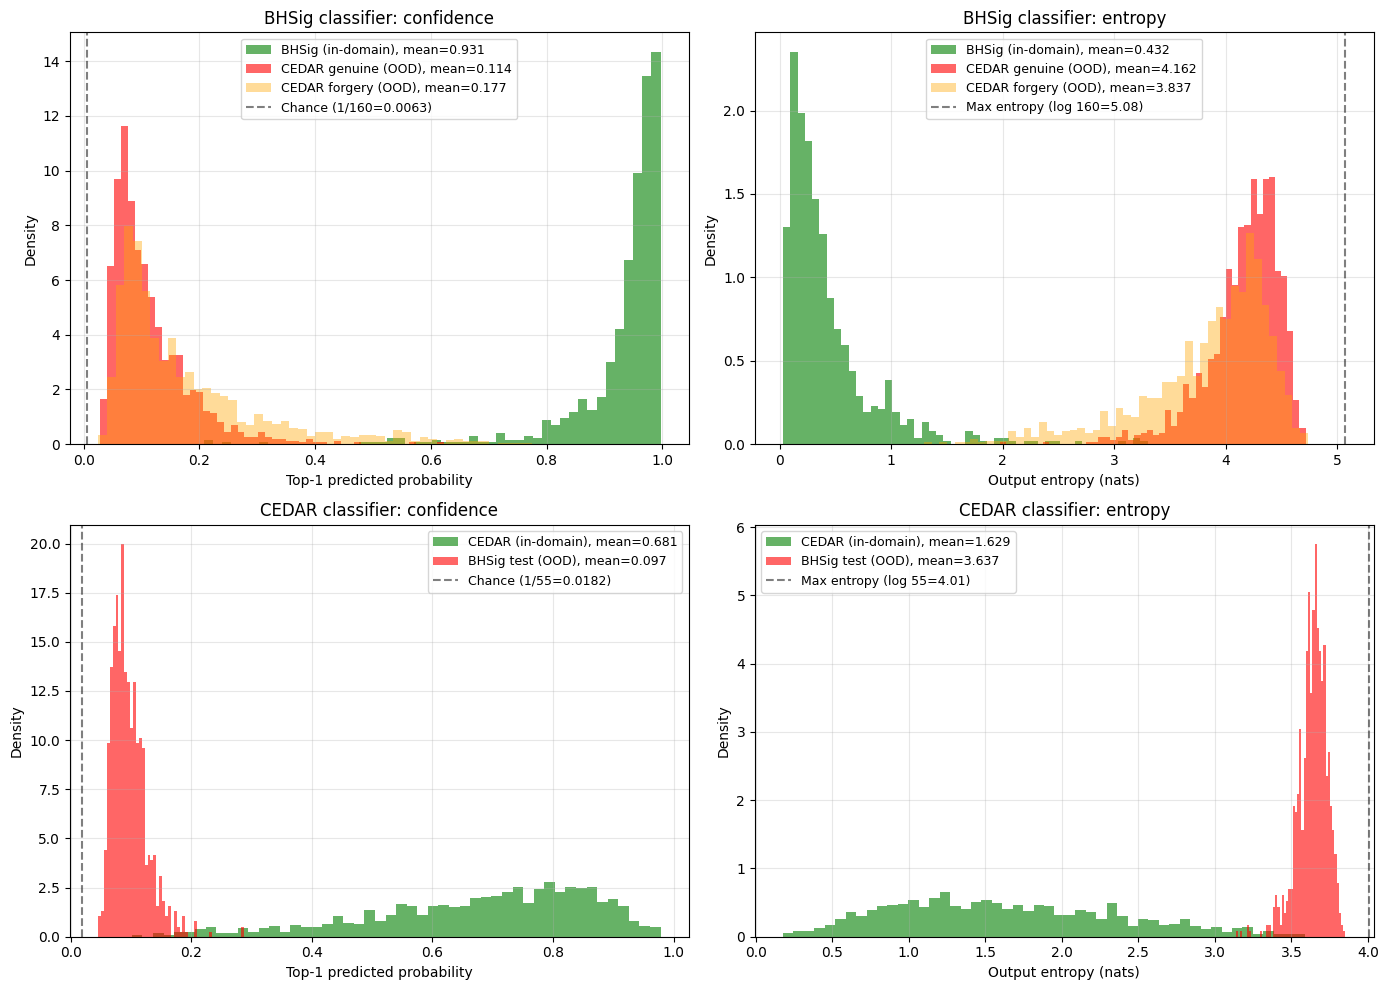

Saved figure to part5_results\confidence_entropy.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-1 probability for BHSig direction
ax = axes[0, 0]
ax.hist(bhsig_on_bhsig["top1_prob"], bins=50, alpha=0.6,
        label=f"BHSig (in-domain), mean={bhsig_on_bhsig['top1_prob'].mean():.3f}",
        color="green", density=True)
ax.hist(bhsig_on_cedar_gen["top1_prob"], bins=50, alpha=0.6,
        label=f"CEDAR genuine (OOD), mean={bhsig_on_cedar_gen['top1_prob'].mean():.3f}",
        color="red", density=True)
ax.hist(bhsig_on_cedar_forg["top1_prob"], bins=50, alpha=0.4,
        label=f"CEDAR forgery (OOD), mean={bhsig_on_cedar_forg['top1_prob'].mean():.3f}",
        color="orange", density=True)
ax.axvline(1.0/bhsig_n, color="black", linestyle="--", alpha=0.5,
           label=f"Chance (1/{bhsig_n}={1.0/bhsig_n:.4f})")
ax.set_xlabel("Top-1 predicted probability")
ax.set_ylabel("Density")
ax.set_title("BHSig classifier: confidence")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Entropy for BHSig direction
ax = axes[0, 1]
max_ent_bh = np.log(bhsig_n)
ax.hist(bhsig_on_bhsig["entropy"], bins=50, alpha=0.6,
        label=f"BHSig (in-domain), mean={bhsig_on_bhsig['entropy'].mean():.3f}",
        color="green", density=True)
ax.hist(bhsig_on_cedar_gen["entropy"], bins=50, alpha=0.6,
        label=f"CEDAR genuine (OOD), mean={bhsig_on_cedar_gen['entropy'].mean():.3f}",
        color="red", density=True)
ax.hist(bhsig_on_cedar_forg["entropy"], bins=50, alpha=0.4,
        label=f"CEDAR forgery (OOD), mean={bhsig_on_cedar_forg['entropy'].mean():.3f}",
        color="orange", density=True)
ax.axvline(max_ent_bh, color="black", linestyle="--", alpha=0.5,
           label=f"Max entropy (log {bhsig_n}={max_ent_bh:.2f})")
ax.set_xlabel("Output entropy (nats)")
ax.set_ylabel("Density")
ax.set_title("BHSig classifier: entropy")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Top-1 probability for CEDAR direction
ax = axes[1, 0]
ax.hist(cedar_on_cedar_gen["top1_prob"], bins=50, alpha=0.6,
        label=f"CEDAR (in-domain), mean={cedar_on_cedar_gen['top1_prob'].mean():.3f}",
        color="green", density=True)
ax.hist(cedar_on_bhsig["top1_prob"], bins=50, alpha=0.6,
        label=f"BHSig test (OOD), mean={cedar_on_bhsig['top1_prob'].mean():.3f}",
        color="red", density=True)
ax.axvline(1.0/cedar_n, color="black", linestyle="--", alpha=0.5,
           label=f"Chance (1/{cedar_n}={1.0/cedar_n:.4f})")
ax.set_xlabel("Top-1 predicted probability")
ax.set_ylabel("Density")
ax.set_title("CEDAR classifier: confidence")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Entropy for CEDAR direction
ax = axes[1, 1]
max_ent_cd = np.log(cedar_n)
ax.hist(cedar_on_cedar_gen["entropy"], bins=50, alpha=0.6,
        label=f"CEDAR (in-domain), mean={cedar_on_cedar_gen['entropy'].mean():.3f}",
        color="green", density=True)
ax.hist(cedar_on_bhsig["entropy"], bins=50, alpha=0.6,
        label=f"BHSig test (OOD), mean={cedar_on_bhsig['entropy'].mean():.3f}",
        color="red", density=True)
ax.axvline(max_ent_cd, color="black", linestyle="--", alpha=0.5,
           label=f"Max entropy (log {cedar_n}={max_ent_cd:.2f})")
ax.set_xlabel("Output entropy (nats)")
ax.set_ylabel("Density")
ax.set_title("CEDAR classifier: entropy")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = PART5_RESULTS_DIR / "confidence_entropy.png"
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_path}")

## Failure illustrations

The "what went wrong" requirement asks for visual examples. The most
informative examples are **OOD images that the model was nevertheless
very confident about** — these are the cases where the model fails
silently. We pick the top-confidence OOD samples for each model and
save them as illustration figures.

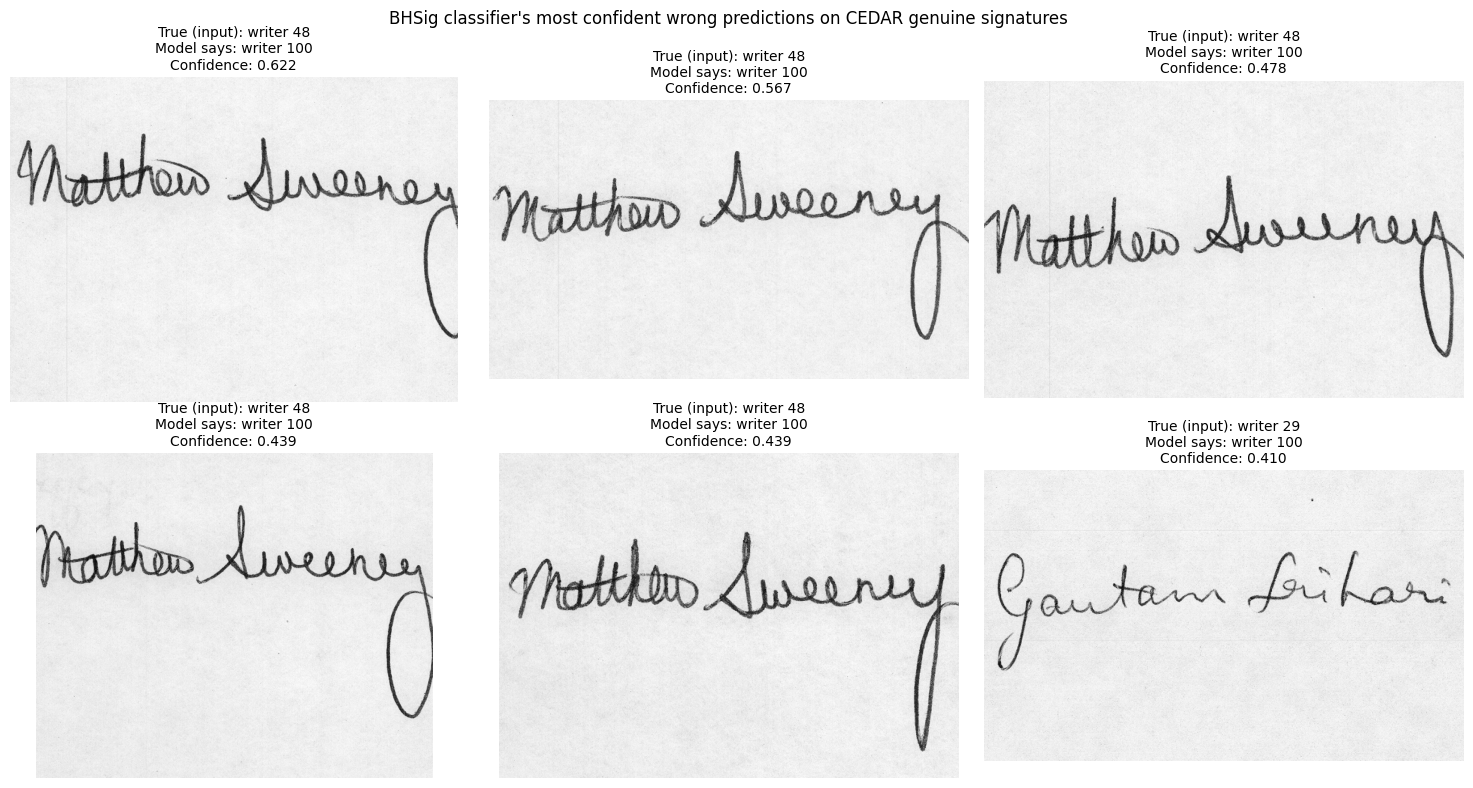

Saved: part5_results\illustrations\bhsig_on_cedar_genuine_top_failures.png


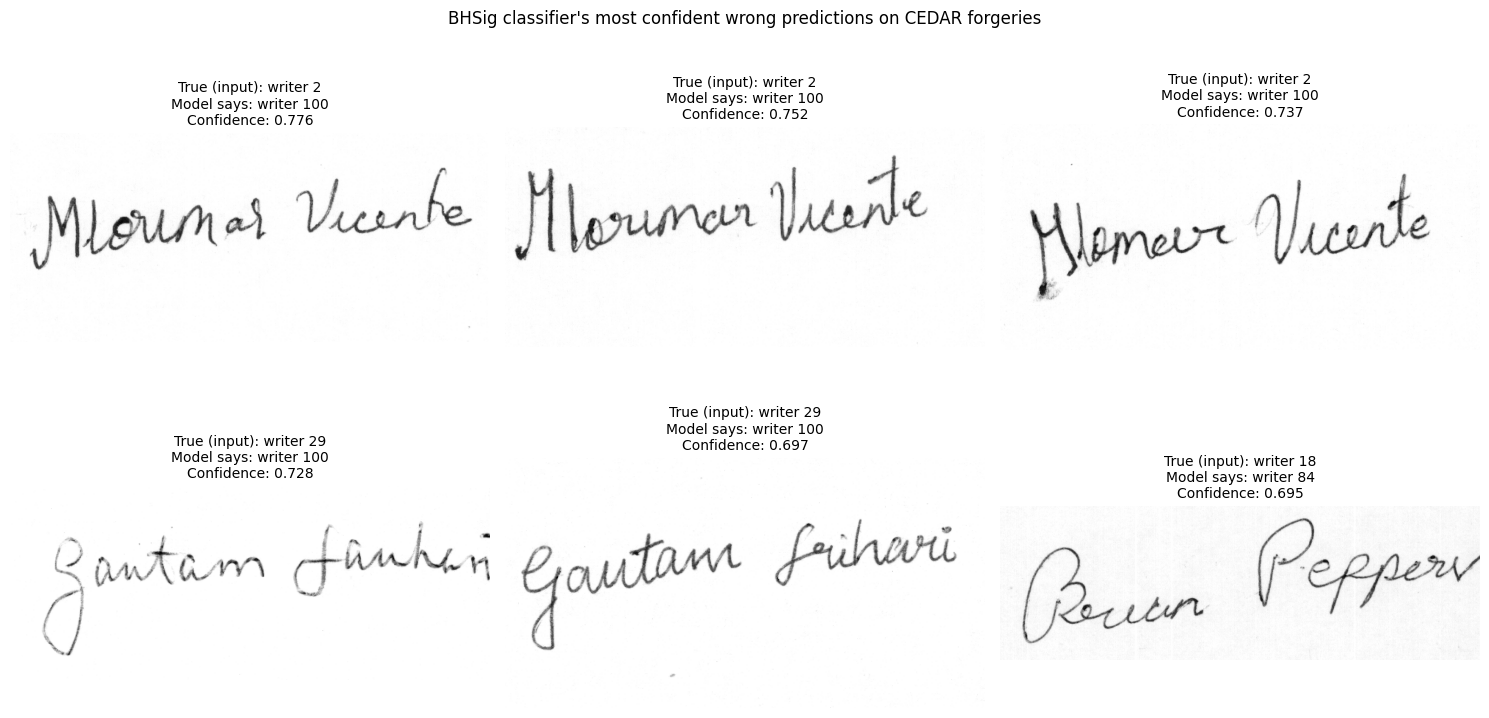

Saved: part5_results\illustrations\bhsig_on_cedar_forgery_top_failures.png


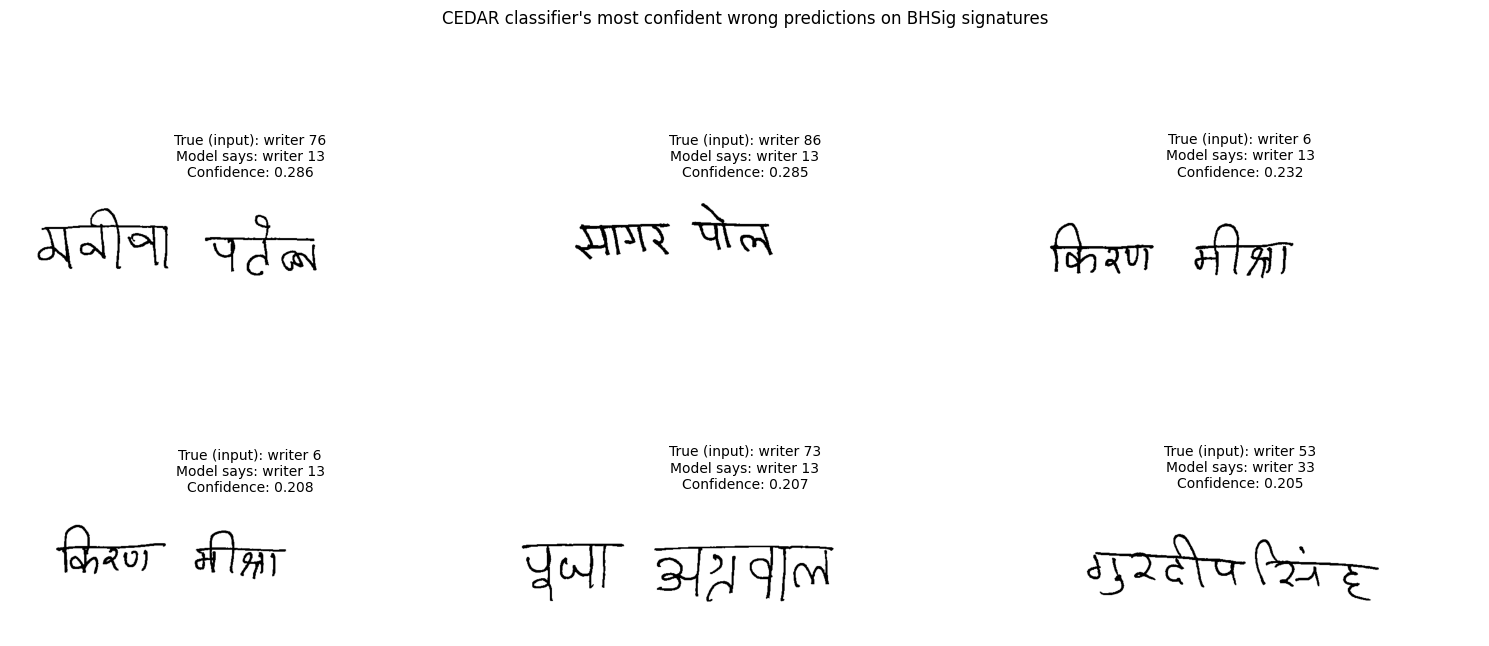

Saved: part5_results\illustrations\cedar_on_bhsig_top_failures.png


In [ ]:
def save_top_confidence_failures(result, image_paths, classifier_classes,
                                  title, n=6):

    probs = result["top1_prob"]
    pred_idx = result["top1_idx"]
    order = np.argsort(probs)[::-1][:n]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for k, src_i in enumerate(order):
        true_writer, img_path = image_paths[src_i]
        img = Image.open(img_path).convert("L")
        ax = axes[k]
        ax.imshow(img, cmap="gray")
        predicted_class_label = classifier_classes[pred_idx[src_i]]
        ax.set_title(
            f"True (input): writer {true_writer}\n"
            f"Model says: writer {predicted_class_label}\n"
            f"Confidence: {probs[src_i]:.3f}",
            fontsize=10,
        )
        ax.axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig


# Save top-confidence failures from each OOD pairing.
fig1 = save_top_confidence_failures(
    bhsig_on_cedar_gen, cedar_genuine_paths, bhsig_classes,
    "BHSig classifier's most confident wrong predictions on CEDAR genuine signatures",
    n=6,
)
fig1_path = ILLUSTRATIONS_DIR / "bhsig_on_cedar_genuine_top_failures.png"
fig1.savefig(fig1_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {fig1_path}")

fig2 = save_top_confidence_failures(
    bhsig_on_cedar_forg, cedar_forgery_paths, bhsig_classes,
    "BHSig classifier's most confident wrong predictions on CEDAR forgeries",
    n=6,
)
fig2_path = ILLUSTRATIONS_DIR / "bhsig_on_cedar_forgery_top_failures.png"
fig2.savefig(fig2_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {fig2_path}")

fig3 = save_top_confidence_failures(
    cedar_on_bhsig, bhsig_test_paths, cedar_classes,
    "CEDAR classifier's most confident wrong predictions on BHSig signatures",
    n=6,
)
fig3_path = ILLUSTRATIONS_DIR / "cedar_on_bhsig_top_failures.png"
fig3.savefig(fig3_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {fig3_path}")

## Genuine vs forgery probe (BHSig classifier viewing CEDAR data)

If the BHSig classifier reacts differently to CEDAR genuine vs CEDAR
forgery images, that would suggest the same paper-texture artifact we
saw in Part 4 (where the CEDAR forgery model exploited it) is also
visible to the BHSig model — i.e., the artifact is a low-level image
property that any CNN would pick up on, not specifically a
CEDAR-classifier behavior.

Two-sample comparison:

In [11]:
from scipy.stats import mannwhitneyu

p_gen = bhsig_on_cedar_gen["top1_prob"]
p_forg = bhsig_on_cedar_forg["top1_prob"]
e_gen = bhsig_on_cedar_gen["entropy"]
e_forg = bhsig_on_cedar_forg["entropy"]

print(f"BHSig classifier confidence on CEDAR genuine:  mean={p_gen.mean():.4f} std={p_gen.std():.4f}")
print(f"BHSig classifier confidence on CEDAR forgery:  mean={p_forg.mean():.4f} std={p_forg.std():.4f}")
print(f"Difference (genuine - forgery): {p_gen.mean() - p_forg.mean():+.4f}")

# Mann-Whitney test for whether the two distributions differ
try:
    stat, pval = mannwhitneyu(p_gen, p_forg, alternative="two-sided")
    print(f"Mann-Whitney U test for confidence difference: U={stat:.0f}, p={pval:.4f}")
except Exception as exc:
    print(f"(scipy not available, skipping statistical test: {exc})")

print()
print(f"BHSig classifier entropy on CEDAR genuine: mean={e_gen.mean():.4f}")
print(f"BHSig classifier entropy on CEDAR forgery: mean={e_forg.mean():.4f}")
print(f"Difference (genuine - forgery): {e_gen.mean() - e_forg.mean():+.4f}")

BHSig classifier confidence on CEDAR genuine:  mean=0.1137 std=0.0675
BHSig classifier confidence on CEDAR forgery:  mean=0.1767 std=0.1320
Difference (genuine - forgery): -0.0629
Mann-Whitney U test for confidence difference: U=597488, p=0.0000

BHSig classifier entropy on CEDAR genuine: mean=4.1622
BHSig classifier entropy on CEDAR forgery: mean=3.8367
Difference (genuine - forgery): +0.3255


## Save numeric results to JSON

In [12]:
def summarize_to_dict(name, result, num_classes):
    p = result["top1_prob"]
    e = result["entropy"]
    return {
        "name": name,
        "n_samples": int(len(p)),
        "num_classes": int(num_classes),
        "chance_prob": float(1.0 / num_classes),
        "max_entropy": float(np.log(num_classes)),
        "mean_top1_prob": float(p.mean()),
        "median_top1_prob": float(np.median(p)),
        "std_top1_prob": float(p.std()),
        "mean_entropy": float(e.mean()),
        "median_entropy": float(np.median(e)),
        "std_entropy": float(e.std()),
    }


summary = {
    "bhsig_indomain_acc": float(bhsig_indomain_acc),
    "cedar_indomain_acc": float(cedar_indomain_acc),
    "evaluations": [
        summarize_to_dict("BHSig model on BHSig test (in-domain)",   bhsig_on_bhsig,      bhsig_n),
        summarize_to_dict("BHSig model on CEDAR genuine (OOD)",       bhsig_on_cedar_gen,  bhsig_n),
        summarize_to_dict("BHSig model on CEDAR forgery (OOD)",       bhsig_on_cedar_forg, bhsig_n),
        summarize_to_dict("CEDAR model on BHSig test (OOD)",          cedar_on_bhsig,      cedar_n),
        summarize_to_dict("CEDAR model on CEDAR genuine (in-domain)", cedar_on_cedar_gen,  cedar_n),
    ],
}

results_path = PART5_RESULTS_DIR / "part5_results.json"
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved results to {results_path}")

Saved results to part5_results\part5_results.json
